# 03 - Network Visualization (ForceAtlas2)

*Consolidated from: `02_view_network.ipynb`*

## Outputs
- `output/figures/fig3_network.png` - Network graph (no labels)
- `output/figures/fig3_network_label.pdf` - Network graph (with labels)

In [1]:
# === Setup ===
import sys
sys.path.append('..')

from config.settings import (
    TmpPaths, OutputPaths, DATA_DIR,
    PARTITION_COLORS, PARTITION_NAMES
)
from src.utils import flatten
from src.data_loader import load_pickle, save_pickle
from src.plotting import setup_plot_style, save_figure

In [2]:
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
from adjustText import adjust_text
import warnings

warnings.filterwarnings('ignore')

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
policy_cited_scopus = load_pickle(TmpPaths.POLICY_CITED_PAPER)
partition_info = load_pickle(TmpPaths.PARTITION_INFO)
partition = policy_cited_scopus.partition.to_dict()

partition_info.loc[10, 'partition_name_GPT4'] = 'Infectious Diseases'

print(f"Papers: {len(policy_cited_scopus)}")

Papers: 230737


In [4]:
color_list = PARTITION_COLORS

def rgb_to_hex(rgb):
    rgb = tuple([int(x * 256 - 0.001) for x in rgb[:3]])
    return '#%02x%02x%02x' % rgb

def adjust_lightness(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return rgb_to_hex(colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2]))

---
## 1. Build Citation Network

In [5]:
eids = set(policy_cited_scopus.index)
edges = flatten([[[k, x] for x in v] 
                 for k, v in policy_cited_scopus.reference.dropna().apply(lambda x: set(x) & eids).items()])
print(f"Raw edges: {len(edges)}")

Raw edges: 849844


In [6]:
G = nx.from_edgelist(edges)
G = max([G.subgraph(c) for c in nx.connected_components(G)], key=len)
print(f"LCC nodes: {len(G.nodes())}")

LCC nodes: 195601


In [7]:
trans = {n: i for i, n in enumerate(G.nodes())}
reverse = {i: n for i, n in enumerate(G.nodes())}

---
## 2. ForceAtlas2 Layout (cuGraph GPU)

In [16]:
import cugraph

edges_gc = pd.DataFrame(G.edges())
edges_gc[0] = edges_gc[0].map(trans)
edges_gc[1] = edges_gc[1].map(trans)
Gc = cugraph.from_edgelist(edges_gc, source=0, destination=1)



In [17]:
pos_by_index_df = cugraph.force_atlas2(
    Gc, 
    jitter_tolerance=0.1, 
    barnes_hut_optimize=True, 
    barnes_hut_theta=0.3, 
    gravity=1
).to_pandas()

pos = {
    reverse[row['vertex']]: (row['y'], row['x'])
    for index, row in pos_by_index_df.iterrows()
}

pos_df = pd.DataFrame(pos).T
pos_df['partition'] = policy_cited_scopus.partition



In [18]:
angle = np.radians(40)
rotation_matrix = np.array([
    [np.cos(angle), -np.sin(angle)],
    [np.sin(angle), np.cos(angle)]
])

coords = pos_df.iloc[:, :2].values
rotated_coords = coords @ rotation_matrix.T

pos_df.iloc[:, 0] = rotated_coords[:, 0]
pos_df.iloc[:, 1] = rotated_coords[:, 1]

print("Rotation applied (40 degrees)")

Rotation applied (40 degrees)


---
## 4. Network Drawing (with Labels)

In [19]:
import scienceplots

plt.style.use(['science'])
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
})
plt.rcParams['text.latex.preamble'] = r'\usepackage{arial}\renewcommand{\familydefault}{\sfdefault}'

Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../output/figures/fig3_network_label.png


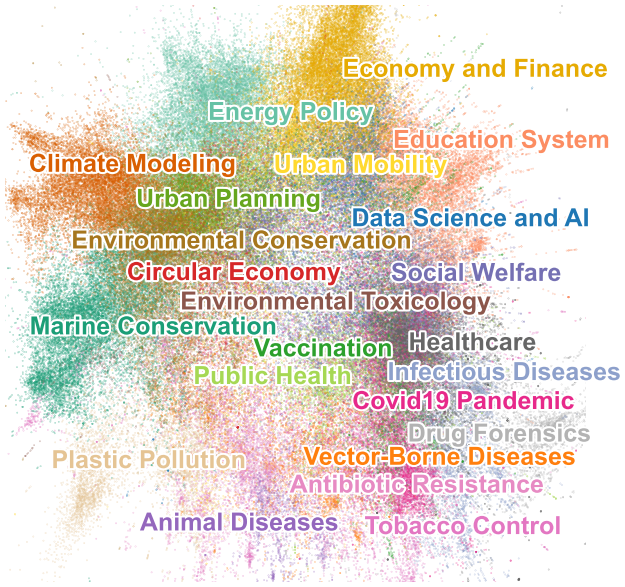

In [95]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))

ax.set_xlim(pos_df[0].quantile([0.005, 0.995]) * 1.1)
ax.set_ylim(pos_df[1].quantile([0.01, 0.98]) * 1.0)

nx.draw(
    G,
    pos={k: (v[0], v[1]) for k, v in pos_df.iterrows()},
    node_color=[color_list[int(partition[n])] for n in G.nodes()],
    node_size=0.03,
    width=0,
    ax=ax,
    alpha=0.8
)

texts = []
for k, v in pos_df.query('partition >= 0').groupby('partition'):
    if len(v) >= 50:
        posx = v[0].median()
        posy = v[1].median()

        label = partition_info.loc[k].partition_name_GPT4.replace("&", "and").strip()
        name = partition_info.loc[k].partition_name_GPT4.replace("&", "and").strip()

        x_adj = 0
        y_adj = 0

        if name == 'Urban Planning':
            x_adj = -4000
            y_adj = 0
        elif name == 'Urban Mobility':
            x_adj = 0
            y_adj = 1000
        elif name == 'Economy and Finance':
            y_adj = 150
            x_adj = 150
        elif name == 'Energy Policy':
            y_adj = 100
        elif name == 'Education System':
            y_adj = 1600
            x_adj = -1500
        elif name == 'Data Science and AI':
            y_adj = -1000
            x_adj = 0
        elif name in ['Circular Economy', 'Cricular Economy']:
            x_adj = -5000
            y_adj = -1000
        elif name == 'Climate Modeling':
            x_adj = -3500
            y_adj = 700
        elif name == 'Infectious Diseases':
            x_adj = -3000
            y_adj = 800
        elif name == 'Covid19 Pandemic':
            y_adj = -150
            x_adj = -2000
        elif name == 'Public Health':
            y_adj = -250
            x_adj = -8000
        elif name == 'Social Welfare':
            y_adj = -850
            x_adj = 3000
        elif name == 'Vector-Borne Diseases':
            y_adj = -450
            x_adj = 350
        elif name == 'Plastic Pollution':
            y_adj = -100
            x_adj = -5500
        elif name == 'Antibiotic Resistance':
            y_adj = -700
            x_adj = 1500
        elif name == 'Vaccination':
            y_adj = 0
            x_adj = -7000
        elif name == 'Marine Conservation':
            y_adj = -200
            x_adj = -3000
        elif name == 'Environmental Conservation':
            y_adj = 200
            x_adj = -5000
        elif name == 'Drug Forensics':
            y_adj = 0
            x_adj = -5000
        elif name == 'Tobacco Control':
            y_adj = 1500
            x_adj = -2000
        elif name == 'Animal Diseases':
            y_adj = -500
            x_adj = -7000

        texts.append(
            ax.annotate(
                f"{label}",
                xy=(posx - 100 + x_adj, posy + y_adj),
                fontsize=18,
                fontweight=600,
                fontname='Arial',
                color=adjust_lightness(color_list[int(k)], 1),
                zorder=4,
                ha='left',
                va='center',
                path_effects=[
                    patheffects.withStroke(
                        linewidth=3,
                        foreground='white',
                        capstyle="round"
                    )
                ]
            )
        )

ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(which='both', length=0)

output_path = OutputPaths.FIGURES / 'fig3_network_label.png'
fig.savefig(output_path, transparent=True, dpi=200)
print(f"Saved: {output_path}")

plt.show()


---
## Output Summary

| File | Description |
|------|-------------|
| `output/figures/fig3_network.png` | Network graph (partition-colored, no labels) |
| `output/figures/fig3_network_label.pdf` | Network graph (with labels, transparent background) |